In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import joblib

In [67]:
## Load train and test data
train_df = pd.read_csv('data/processed/train.csv', index_col=0)
test_df = pd.read_csv('data/processed/test.csv', index_col=0)
data = pd.read_csv('data/raw/used_cars.csv')

In [68]:
y_train = train_df['price_usd']
y_test = test_df['price_usd']

In [69]:
model = joblib.load('models/model.pkl')

In [70]:
y_pred = model.predict(test_df.drop(columns=['price_usd']))

In [71]:
# Evaluate the model with evaluatoin  metrics
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 0.005024422886736926
Mean Absolute Error: 0.0495812232629578
R2 Score: 0.7573617090532845


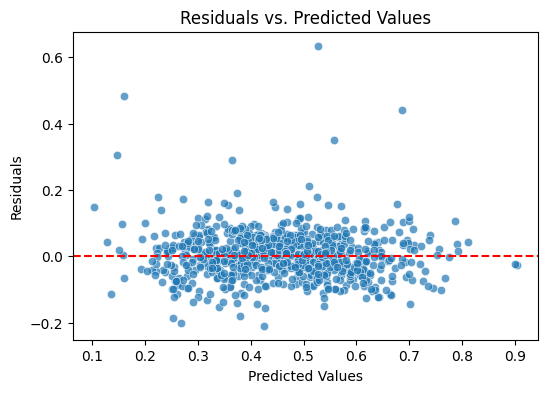

In [72]:
# 1. Calculate residuals correctly (Actual - Predicted)
residuals = y_test - y_pred 

plt.figure(figsize=(6, 4))
# 2. Set x to your predictions, and y to your residuals
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--') 

plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')  # Matches x=y_pred
plt.ylabel('Residuals')         # Matches y=residuals
plt.show()


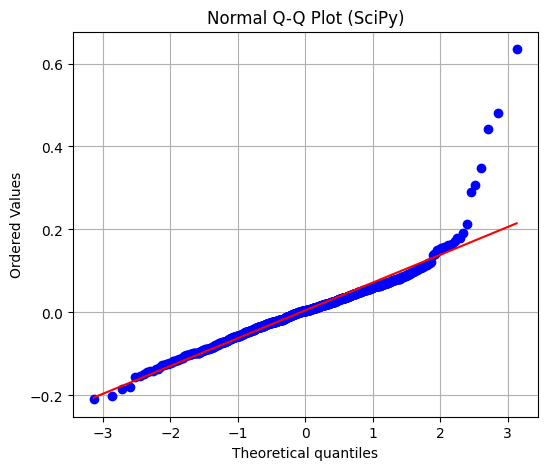

In [73]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 2. Generate the Q-Q plot (Changed "normal" to "norm")
plt.figure(figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=plt)

# 3. Customize and display
plt.title("Normal Q-Q Plot (SciPy)")
plt.grid(True)
plt.show()


<Axes: xlabel='price_usd', ylabel='Count'>

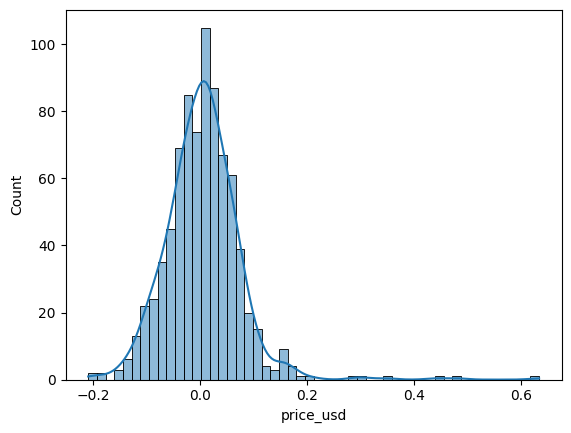

In [74]:
sns.histplot(residuals, kde=True)

In [75]:
train_pred = model.predict(train_df.drop(columns=['price_usd']))

r2 = r2_score(train_df['price_usd'], train_pred)
mse = mean_squared_error(train_df['price_usd'], train_pred)
rmse = np.sqrt(mse)

print(r2)
print(mse)
print(rmse)

0.8044800786720635
0.003983282132036203
0.06311324846683304


In [76]:
test_pred = model.predict(test_df.drop(columns=['price_usd']))
r2 = r2_score(test_df['price_usd'], test_pred)
mse = mean_squared_error(test_df['price_usd'], test_pred)
rmse = np.sqrt(mse)
print(r2)
print(mse)
print(rmse)

0.7573617090532845
0.005024422886736926
0.07088316363380606


## Multicollenearity

In [77]:
# Check multicollenearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(train_df)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# 4. Calculate VIF for each column
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. Drop the artificial constant row and SORT from highest to lowest
vif_sorted = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_sorted)


                     Feature         VIF
0                      const  292.576012
1              ext_col_Black   17.684061
2               ext_col_Gray   17.100909
3              ext_col_White   16.751812
4               ext_col_Blue    8.659713
5                ext_col_Red    7.178998
6         fuel_type_Gasoline    5.552113
7                ext_col_nan    5.479118
8                  price_usd    5.114568
9         fuel_type_Electric    3.792303
10               mileage_num    3.101131
11                 engine_hp    3.064313
12          fuel_type_Hybrid    2.952472
13       engine_displacement    2.716138
14                model_year    2.687835
15           is_high_mileage    2.493378
16             int_col_Black    2.447040
17            ext_col_Orange    2.446848
18   fuel_type_E85 Flex Fuel    2.316545
19             ext_col_Brown    2.051532
20              int_col_Gray    1.750730
21                     brand    1.639833
22  fuel_type_Plug-In Hybrid    1.409808
23             i

## Checking influential/ leverage points



In [78]:
import statsmodels.api as sm

y = train_df['price_usd']

model = sm.OLS(y,add_constant(train_df.drop(columns=['price_usd']))).fit()

influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

In [79]:
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

In [80]:
cooks_d

array([1.57086713e-04, 9.68561849e-06, 2.63159998e-06, ...,
       8.23776004e-06, 3.85963656e-04, 6.53120593e-04], shape=(3125,))

In [81]:
leverage = influence.hat_matrix_diag
residuals = model.resid

In [82]:
import numpy as np

n = len(X)
threshold = 4 / n

influential = np.where(cooks_d > threshold)[0]

In [83]:
data.iloc[influential].to_csv("influential.csv")

In [84]:
data.iloc[[93, 853]]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
93,Aston,Martin DBS Superleggera,2021,"2,165 mi.",Gasoline,5.2L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,Black,Black,None reported,Yes,"$279,950"
853,Toyota,Highlander Base,2001,"231,581 mi.",Gasoline,220.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Beige,Beige,None reported,Yes,"$4,300"


In [85]:
len(influential)

188

<Axes: >

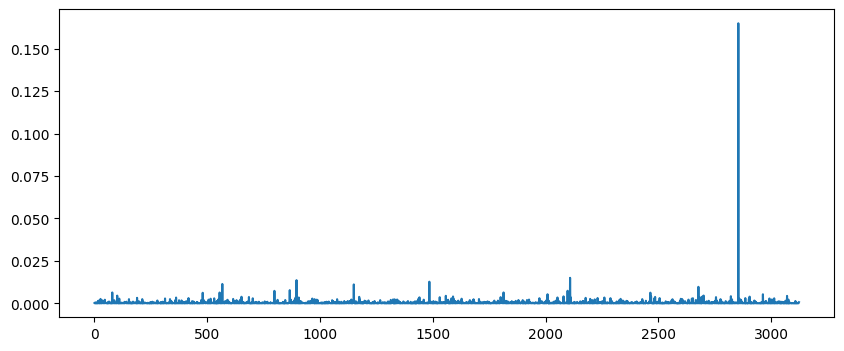

In [86]:
# 1. Fix the Series argument from column to name
cooks_d = pd.Series(cooks_d, name='cooks_d')

# 2. Use a line plot instead of a bar plot for Cook's Distance
cooks_d.plot(kind='line', figsize=(10, 4))


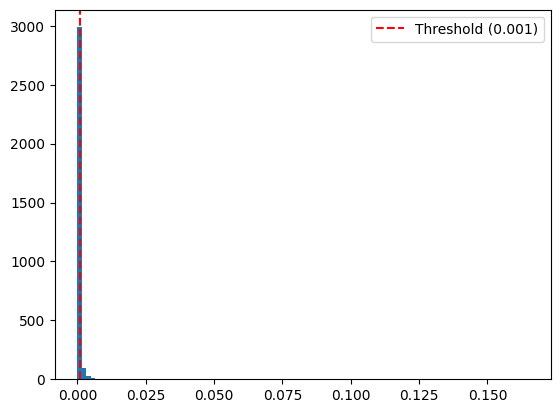

In [87]:
# Your existing histogram code
plt.hist(cooks_d, bins=100)

# Add a vertical threshold line
plt.axvline(x=0.001, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.001)')

# Add a legend to identify the line
plt.legend()

# Display the plot
plt.show()

## Linearity assesment

In [88]:
X = add_constant(train_df.drop(columns = ['price_usd']))
model = sm.OLS(train_df['price_usd'], X).fit() 

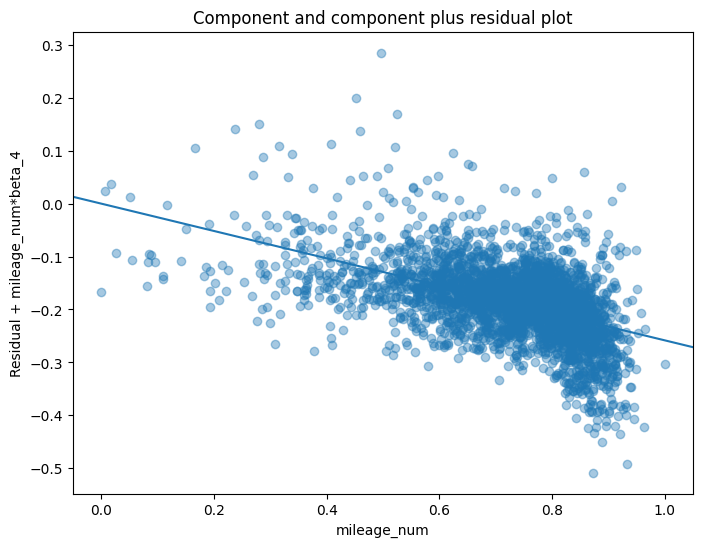

In [89]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# assuming 'model' is your fitted statsmodels OLS object
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ONLY mileage_num to inspect its linearity
sm.graphics.plot_ccpr(model, "mileage_num", ax=ax)
ax.lines[0].set_alpha(0.4)  
plt.show()

<Axes: >

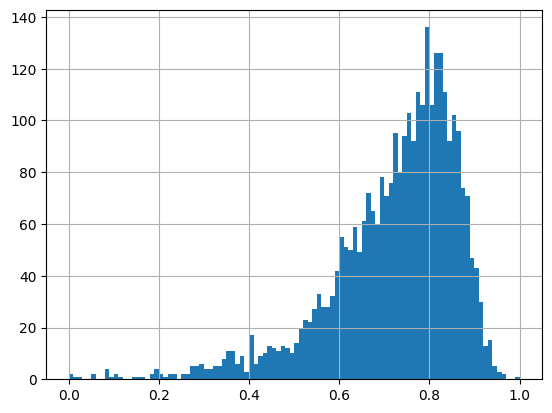

In [95]:
train_df['mileage_num'].hist(bins=100)

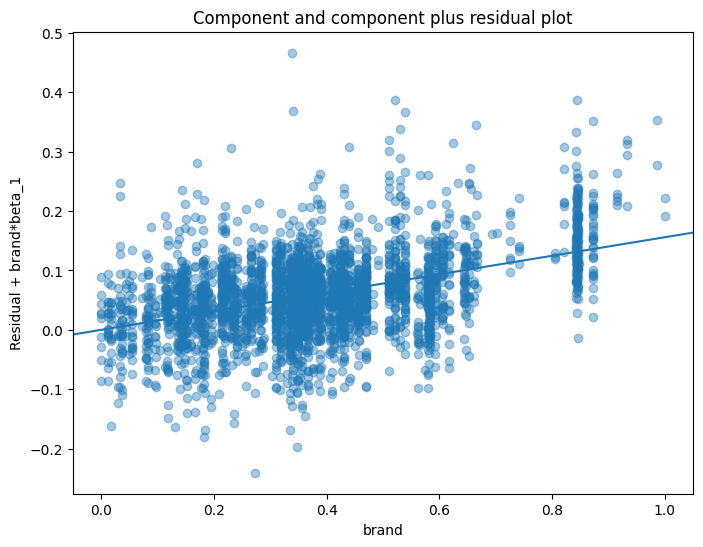

In [90]:
# assuming 'model' is your fitted statsmodels OLS object
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ONLY mileage_num to inspect its linearity
sm.graphics.plot_ccpr(model, "brand", ax=ax)
ax.lines[0].set_alpha(0.4)  
plt.show()

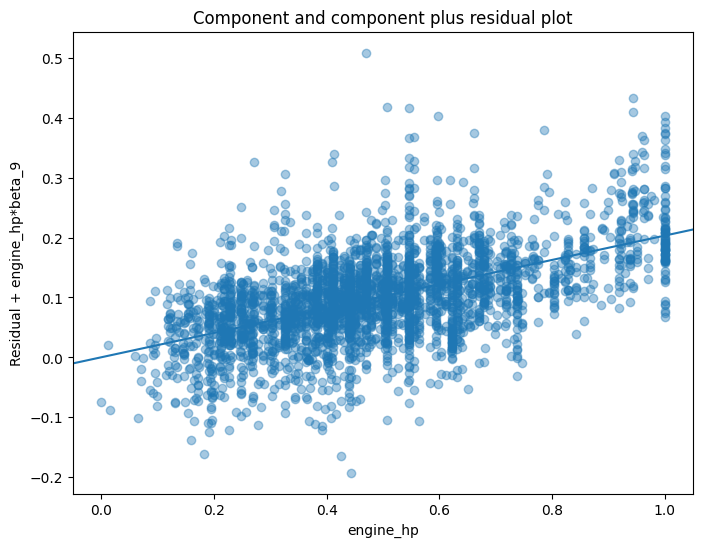

In [91]:
# assuming 'model' is your fitted statsmodels OLS object
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ONLY mileage_num to inspect its linearity
sm.graphics.plot_ccpr(model, "engine_hp", ax=ax)
ax.lines[0].set_alpha(0.4)  
plt.show()

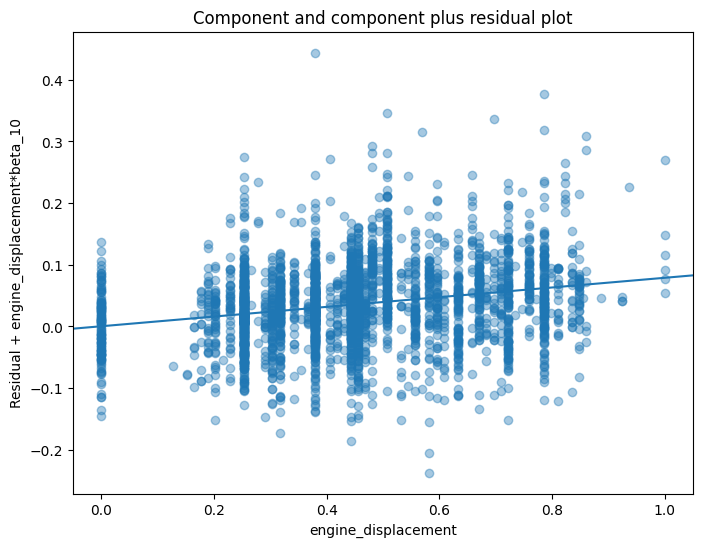

In [92]:
# assuming 'model' is your fitted statsmodels OLS object
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ONLY mileage_num to inspect its linearity
sm.graphics.plot_ccpr(model, "engine_displacement", ax=ax)
ax.lines[0].set_alpha(0.4)  
plt.show()

In [93]:
train_df.info().to_clipboard()

<class 'pandas.DataFrame'>
Index: 3125 entries, 2474 to 3175
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   brand                     3125 non-null   float64
 1   model_year                3125 non-null   float64
 2   accident                  3125 non-null   float64
 3   price_usd                 3125 non-null   float64
 4   mileage_num               3125 non-null   float64
 5   has_clean_title           3125 non-null   float64
 6   is_sport                  3125 non-null   float64
 7   is_premium                3125 non-null   float64
 8   is_4WD_AWD                3125 non-null   float64
 9   engine_hp                 3125 non-null   float64
 10  engine_displacement       3125 non-null   float64
 11  fuel_type_E85 Flex Fuel   3125 non-null   float64
 12  fuel_type_Electric        3125 non-null   float64
 13  fuel_type_Gasoline        3125 non-null   float64
 14  fuel_type_Hybrid     

AttributeError: 'NoneType' object has no attribute 'to_clipboard'